<a href="https://colab.research.google.com/github/MOUMEN1989/Ecole-Doctorale-2026/blob/main/Prediction_de_risque_de_faillite_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bibliothèques importées avec succès.
Aperçu des 5 premières lignes du jeu de données:


,Caracteristique_X1,Caracteristique_X2,Caracteristique_X3,Cible_y
0,9.955871,8.044099,1.950026,35.149590
1,3.569704,8.533458,1.496456,25.573005
2,6.116880,8.270493,3.022970,27.765257
3,7.712006,8.882016,3.879842,33.303890
4,3.577452,7.250705,6.801278,18.885812



Le jeu de données contient 100 observations et 3 caractéristiques.

Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Caracteristique_X1  100 non-null    float64
 1   Caracteristique_X2  100 non-null    float64
 2   Caracteristique_X3  100 non-null    float64
 3   Cible_y             100 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB


None

Taille de l'ensemble d'entraînement (X_train): (80, 1)
Taille de l'ensemble de test (X_test): (20, 1)
Modèle de régression linéaire entraîné avec succès.
Coefficient (pente): 1.89
Ordonnée à l'origine: 10.78

Métriques d'évaluation du modèle:
Erreur Absolue Moyenne (MAE): 4.43
Erreur Quadratique Moyenne (MSE): 27.35
Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): 5.23
Coefficient de Détermination (R²): 0.52


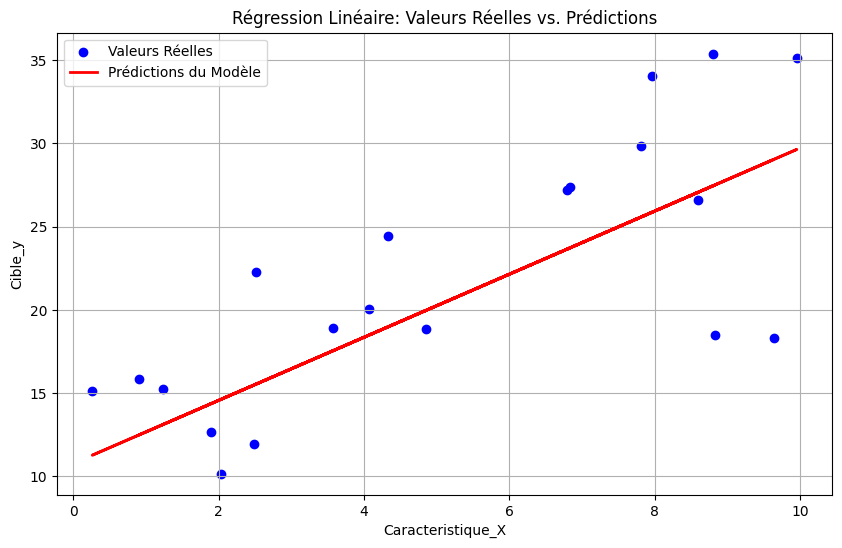

Nombre d'observations : 20640
Nombre de variables (features) : 8

Exemple de 5 premières lignes :
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Statistiques descriptives des variables numériques :
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
A

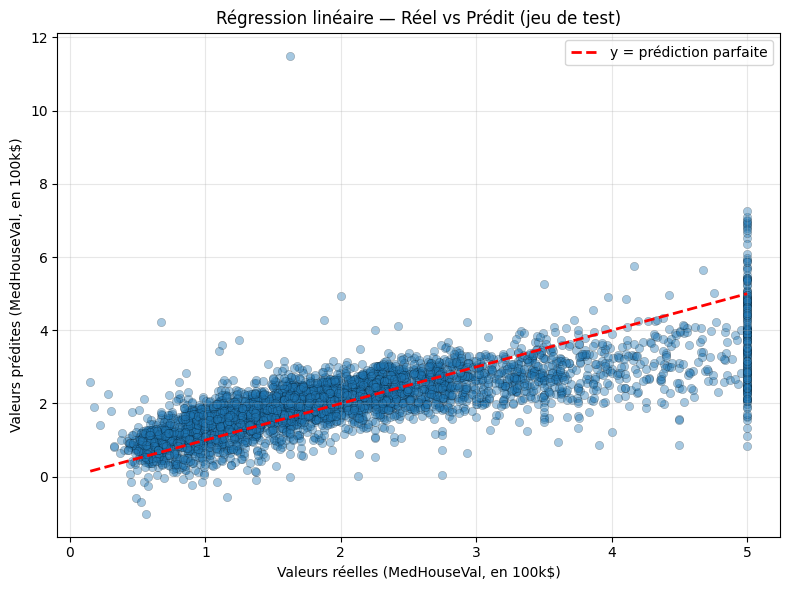

NameError: name 'residuals' is not defined

<Figure size 800x400 with 0 Axes>

In [4]:
#Exemple 2
# -*- codage : utf-8 -*-
"""Regression.ipynb

Généré automatiquement par Colab.

Le fichier original se trouve à
    https://colab.research.google.com/drive/1IovhO2W7vebpRo96GB9KgUa2yA6z3zYw

## Régression Linéaire : Exemple Complet en Python

Cet exemple démontrer comment effectuer une régression linéaire simple en utilisant les bibliothèques `scikit-learn`, `pandas`, `numpy` et `matplotlib`.
"""

# 1. Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Ajout de seaborn pour des visualisations améliorées
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliothèques importées avec succès.")

"""### 2. Génération et Exploration des Données Synthétiques

Nous allons créer un jeu de données synthétiques pour illustrer le processus de régression linéaire. Ce jeu de données aura une variable indépendante (caractéristique) `X` et une variable dépendante (cible) `y`, avec une relation linéaire et un peu de bruit.
"""

# Nombre d'observations et de variables
n_observations = 100
n_features = 3 # Ajout de plusieurs variables indépendantes pour des visualisations plus riches

# Génération des variables indépendantes X
X = np.random.rand(n_observations, n_features) * 10 # Valeurs aléatoires entre 0 et 10 pour 3 caractéristiques

# Génération de la variable dépendante y avec une relation linéaire et du bruit
# Exemple : y = 2*X1 + 1,5*X2 - 0.5*X3 + 5 + bruit_aléatoire
coefficients = np.array([2, 1.5, -0.5])
y = np.dot(X, coefficients) + 5 + np.random.randn(n_observations) * 2

# Création d'un DataFrame Pandas pour une meilleure manipulation
column_names = [f'Caracteristique_X{i+1}' for i in range(n_features)]
data = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=column_names + ['Cible_y'])

# Exploration rapide des données
print("Aperçu des 5 premières lignes du jeu de données:")
display(data.head())

print(f"\nLe jeu de données contient {n_observations} observations et {n_features} caractéristiques.")
print("\nInformations sur le jeu de données:")
display(data.info())

"""### 3. Séparation des Données en Ensembles d'Entraînement et de Test

Pour évaluer la performance de notre modèle sur des données qu'il n'a jamais vues, nous divisons le jeu de données en un ensemble d'entraînement (pour apprendre) et un ensemble de test (pour évaluation). Généralement, un ratio de 80/20 ou 70/30 est utilisé.
"""

# Séparation de X et y
X = data[['Caracteristique_X1']]
y = data['Cible_y']

# Séparation des données en 80% entraînement et 20% test
# `random_state` assure la reproductibilité de la séparation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")

"""### 4. Entraînement du Modèle de Régression Linéaire

Nous allons instancier le modèle `LinearRegression` de `scikit-learn` et l'entraîner sur nos données d'entraînement.
"""

# Création de l'objet régresseur linéaire
model = LinearRegression()

# Entraînement du modèle sur les données d'entraînement
model.fit(X_train, y_train)

print("Modèle de régression linéaire entraîné avec succès.")
print(f"Coefficient (pente): {model.coef_[0]:.2f}")
print(f"Ordonnée à l'origine: {model.intercept_:.2f}")

"""### 5. Prédiction et Évaluation du Modèle

Après l'entraînement, nous utilisons le modèle pour faire des prédictions sur l'ensemble de test et nous évaluons sa performance à l'aide de métriques courantes.
"""

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nMétriques d'évaluation du modèle:")
print(f"Erreur Absolue Moyenne (MAE): {mae:.2f}")
print(f"Erreur Quadratique Moyenne (MSE): {mse:.2f}")
print(f"Racine Carrée de l'Erreur Quadratique Moyenne (RMSE): {rmse:.2f}")
print(f"Coefficient de Détermination (R²): {r2:.2f}")

"""#### Interprétation des Métriques:

* **Erreur Absolue Moyenne (MAE)**: C'est la moyenne des erreurs absolues entre les prédictions et les valeurs réelles. Elle donne une idée de l'erreur typique dans les prédictions, dans les mêmes unités que la variable cible. Un MAE de 1.62 signifie qu'en moyenne, les prédictions du modèle sont à 1.62 unités des valeurs réelles.

* **Erreur Quadratique Moyenne (MSE)** : C'est la moyenne des carrés des erreurs. Elle pénalise davantage les grandes erreurs. Elle est utile pour comprendre l'ampleur des erreurs, mais sa valeur n'est pas directement interprétable dans les unités de la cible. Un MSE de 3.96 indique une dispersion des erreurs.

* **Racine Carrée de l'Erreur Quadratique Moyenne (RMSE)** : C'est la racine carrée du MSE. Elle est dans les mêmes unités que la variable cible, ce qui la rend plus interprétable que le MSE. Un RMSE de 1,99 signifie que l'écart type des erreurs de prédiction est d'environ 1,99 unités.

* **Coefficient de Détermination (R²)** : Il représente la proportion de la variance de la variable dépendante qui est visible à partir des variables indépendantes. Sa valeur est comprise entre 0 et 1 (voire négative dans de rares cas si le modèle est très mauvais). Un R² de 0.90 signifie que 90% de la variance de `Cible_y` est expliquée par notre modèle de régression linéaire. Un R² plus proche de 1 indique un meilleur ajustement du modèle aux données.

### 6. Visualisation des résultats

Il est utile de visualiser les valeurs réelles par rapport aux valeurs prédites pour avoir une compréhension graphique de la performance du modèle.
"""

# Création d'un graphique de dispersion
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Valeurs Réelles')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Prédictions du Modèle')

plt.title('Régression Linéaire: Valeurs Réelles vs. Prédictions')
plt.xlabel('Caracteristique_X')
plt.ylabel('Cible_y')
plt.legend()
plt.grid(True)
plt.show()

# Message d'Abderrahim Larhlimi
# Abderrahim Larhlimi
# Créé à 16h2216h22
#exemple de code
# -*- coding: utf-8 -*-
"""Untitled108.ipynb

Généré automatiquement par Colab.

Le fichier original se trouve à l'adresse
    https://colab.research.google.com/drive/1PqHReNbh9mCFFsdm__1a-ozVTmzLMmOo
"""

# Exemple complet de régression linéaire en Python
# Bibliothèques : scikit-learn, pandas, numpy, matplotlib
# Prêt à exécuter (Python 3.8+ recommandé)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Chargement et exploration rapide des données
# ---------------------------------------------------------------------
california = fetch_california_housing(as_frame=True)
X = california.data # DataFrame des caractéristiques
y = california.target # Série des cibles (median house value, en 100k$)
df = pd.concat([X, y.rename("MedHouseVal")], axis=1)

# Nombre d'observations et de variables
n_obs, n_vars = X.shape
print(f"Nombre d'observations : {n_obs}")
print(f"Nombre de variables (features) : {n_vars}")

# Affichage rapide
print("\nExemple de 5 premières lignes :")
print(df.head())

print("\nStatistiques descriptives des variables numériques :")
print(df.describe().T)

# (Optionnel) matrice de corrélation rapide
print("\nCorrélations (avec la variable cible triées par valeur absolue) :")
corr_with_target = df.corr()["MedHouseVal"].abs().sort_values(ascending=False)
print(corr_with_target)

# Brève explication :
# - Le dataset California Housing contient des observations (n_obs) de quartiers,
# avec plusieurs variables explicatives (n_vars) telles que MedInc, HouseAge, etc.
# - La cible `MedHouseVal` est la valeur médiane des maisons (en 100k$).

# 2) Séparation train/test (80/20)
# --------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTaille train : {X_train.shape[0]} observations")
print(f"Taille test : {X_test.shape[0]} observations")

# 3) Entraînement du modèle
# ------------------------------------------------------------------------------------
model = LinearRegression()
model.fit(X_train,y_train)

# Optionnel : coefficients du modèle (interprétation linéaire)
coeffs = pd.Series(model.coef_, index=X.columns)
print("\nCoefficients du modèle (feature coef) :")
print(coeffs.sort_values(key=abs, ascending=False))

# 4) Prédiction et évaluation (R², MAE, RMSE)
# ---------------------------------------------------------------------
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calcule RMSE en prenant la racine carrée du MSE

print("\nMétriques d'évaluation sur le jeu de test :")
print(f"R² : {r2:.4f}")
print(f"MAE : {mae:.4f} (unité = valeur médiane de la maison en 100k$)")
print(f"RMSE : {rmse:.4f} (unité = valeur médiane de la maison en 100k$)")

# 5) Visualisation des résultats (valeurs réelles vs prédites)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='y = prédiction parfaite')
plt.xlabel("Valeurs réelles (MedHouseVal, en 100k$)")
plt.ylabel("Valeurs prédites (MedHouseVal, en 100k$)")
plt.title("Régression linéaire — Réel vs Prédit (jeu de test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Visualisation des résidus (optionnel)
résiduels = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des résidus (y_test - y_pred)")
plt.xlabel("Résidu (en 100k$)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# Brève explication finale et interprétation des métriques :
# ------------------------------------------------------------------------------------
# - R² (coefficient de détermination) : proportion de la variance de la variable
# cible expliquée par le modèle. Varie entre -inf et 1. Une valeur proche de 1
# signifie que le modèle explique bien la variabilité des données.
# Interprétation pratique :
# * R² >= 0.7 : excellent (pour beaucoup de problèmes réels, rare en pratique)
# * 0.4 <= R² < 0.7 : raisonnable/modéré
# * R² < 0.4 : faible (le modèle linéaire n'explique pas bien la cible)
#
# - MAE (Mean Absolute Error) :erreur moyenne absolue entre prédictions et réelles.
# Donne une idée en unités de la cible (ici 100k$). Plus petit est le meilleur.
#
# - RMSE (Root Mean Squared Error) : racine de l'erreur quadratique moyenne.
# Pénalise davantage les grandes erreurs que le MAE. Interprétation :
# * Si RMSE est petit comparé à l'échelle typique de la cible, les prédictions
# sont précises. Par exemple, si la médiane des maisons est ~2.0 (200k$)
# et RMSE = 0.5, l'erreur-type est ~50k$.
#
# Exemples d'interprétation concrète (avec valeurs fictives) :
# - Si R² = 0.60, MAE = 0.40, RMSE = 0.60 :
# Le modèle explique ~60% de la variance ; l'erreur moyenne est 40k$,
# l'erreur-type (RMSE) est 60k$. Les prédictions sont utiles mais encore
# loin d'être parfaites pour des décisions très sensibles au prix.
#
# Remarques pratiques :
# - La régression linéaire est simple et interprétable ; si R² est faible,
# penser à : ingénierie des fonctionnalités, transformations (log, polynômes),
# régularisation (Ridge/Lasso), ou modèles non-linéaires (RandomForest, XGBoost).
# - Toujours vérifier les résidus (non corrélation, distribution proche de 0)
# pour valider certaines hypothèses du modèle linéaire.
#
# Fin de l'exemple.

### Explication Détaillée des Étapes

Ce notebook démontre un exemple complet de régression linéaire en Python. La régression linéaire est une technique statistique largement utilisée pour modéliser la relation linéaire entre une variable dépendante continue et une ou plusieurs variables indépendantes. Voici une explication détaillée de chaque étape.

#### 1. Importation des bibliothèques nécessaires

Cette section importe toutes les bibliothèques Python nécessaires pour la tâche de régression linéaire. Voici leur rôle:

*   **`pandas` (pd)**: Utilisé pour la manipulation et l'analyse des données. Il est excellent pour travailler avec des tableaux de données (DataFrames).
*   **`numpy` (np)**: Fournit un support pour les tableaux et matrices de grande taille, ainsi qu'une collection de fonctions mathématiques pour opérer sur ces tableaux.
*   **`matplotlib.pyplot` (plt)**: Une bibliothèque complète pour créer des visualisations statiques, animées et interactives en Python.
*   **`seaborn` (sns)**: Basé sur `matplotlib`, il offre une interface de haut niveau pour dessiner des graphiques statistiques attrayants et informatifs.
*   **`sklearn.model_selection.train_test_split`**: Une fonction de Scikit-learn qui divise les données en ensembles d'entraînement et de test aléatoires.
*   **`sklearn.linear_model.LinearRegression`**: La classe de modèle pour la régression linéaire de Scikit-learn.
*   **`sklearn.metrics.mean_absolute_error`, `mean_squared_error`, `r2_score`**: Fonctions de Scikit-learn pour évaluer la performance du modèle de régression.

Le `print` final confirme que toutes les bibliothèques ont été chargées avec succès.

#### 2. Génération et Exploration des Données Synthétiques

Dans cette étape, nous créons un jeu de données artificiel pour simuler un scénario de régression linéaire. Cela nous permet de contrôler les relations sous-jacentes et de comprendre comment le modèle apprend.

*   **`n_observations = 100`**: Définit le nombre de points de données que nous allons générer.
*   **`n_features = 3`**: Spécifie le nombre de variables indépendantes (caractéristiques) dans notre jeu de données.
*   **`X = np.random.rand(n_observations, n_features) * 10`**: Génère un tableau NumPy `X` de taille (100, 3) contenant des nombres aléatoires uniformément distribués entre 0 et 10. Ces valeurs représentent nos caractéristiques d'entrée.
*   **`y = np.dot(X, coefficients) + 5 + np.random.randn(n_observations) * 2`**: Crée la variable dépendante `y`. Elle est calculée comme une combinaison linéaire des caractéristiques `X` (multipliées par `coefficients` `[2, 1.5, -0.5]`), ajoutée d'une constante `5`, et perturbée par un bruit aléatoire (`np.random.randn(n_observations) * 2`) pour simuler des données du monde réel.
*   **`data = pd.DataFrame(...)`**: Combine les caractéristiques `X` et la cible `y` en un `DataFrame` Pandas pour une manipulation plus facile, en leur donnant des noms de colonnes significatifs (`Caracteristique_X1`, `Caracteristique_X2`, `Caracteristique_X3`, `Cible_y`).

L'exploration rapide (`data.head()` et `data.info()`) permet de vérifier la structure des données, les types de données des colonnes et la présence de valeurs manquantes (qui ne sont pas attendues ici car les données sont synthétiques).

#### 3. Séparation des Données en Ensembles d'Entraînement et de Test

Cette étape est cruciale pour évaluer de manière fiable la performance de notre modèle. Nous divisons notre jeu de données en deux parties:

*   **Ensemble d'entraînement (training set)**: Utilisé pour entraîner le modèle. Le modèle apprendra les relations entre `X_train` et `y_train`.
*   **Ensemble de test (testing set)**: Utilisé pour évaluer la performance du modèle sur des données qu'il n'a jamais vues pendant l'entraînement. Cela donne une indication plus réaliste de la capacité du modèle à généraliser.

*   **`X = data[['Caracteristique_X1']]`**: Ici, nous sélectionnons seulement la colonne 'Caracteristique_X1' comme notre variable indépendante (feature) pour le modèle de régression linéaire. C'est un cas de régression linéaire simple (une seule variable explicative).
*   **`y = data['Cible_y']`**: Sélectionne la colonne 'Cible_y' comme notre variable dépendante (target).
*   **`train_test_split(X, y, test_size=0.2, random_state=42)`**: Cette fonction divise `X` et `y`.
    *   `test_size=0.2`: Indique que 20% des données seront utilisées pour l'ensemble de test, et les 80% restants pour l'entraînement.
    *   `random_state=42`: Un entier utilisé pour l'initialisation du générateur de nombres aléatoires. Il garantit que la séparation des données est la même à chaque exécution, rendant les résultats reproductibles.

Les affichages des `shape` (dimensions) des ensembles `X_train`, `X_test` confirment que la séparation a été effectuée correctement.

#### 4. Entraînement du Modèle de Régression Linéaire

C'est l'étape où le modèle 'apprend' des données.

*   **`model = LinearRegression()`**: Crée une instance du modèle de régression linéaire. À ce stade, le modèle est vide, il n'a pas encore appris de relations.
*   **`model.fit(X_train, y_train)`**: C'est la commande d'entraînement. Le modèle ajuste ses paramètres (coefficient et ordonnée à l'origine) pour trouver la meilleure ligne droite qui minimise l'erreur entre les valeurs prédites et les valeurs réelles dans l'ensemble d'entraînement.
    *   **`model.coef_[0]`**: Après l'entraînement, cette propriété contient le coefficient (ou la pente) de la relation linéaire. Il indique de combien `y` change pour une unité de changement dans `X`.
    *   **`model.intercept_`**: Cette propriété contient l'ordonnée à l'origine (ou l'interception), c'est-à-dire la valeur de `y` lorsque `X` est égal à zéro.

Les valeurs affichées (`Coefficient` et `Ordonnée à l'origine`) nous donnent une idée de la relation linéaire que le modèle a apprise.

#### 5. Prédiction et Évaluation du Modèle

Une fois le modèle entraîné, nous l'utilisons pour faire des prédictions et évaluer sa performance sur les données de test.

*   **`y_pred = model.predict(X_test)`**: Le modèle utilise les caractéristiques (`X_test`) qu'il n'a pas vues pendant l'entraînement pour prédire les valeurs de la variable cible (`y_pred`).
*   **Calcul des métriques d'évaluation**: Nous utilisons plusieurs métriques pour quantifier la performance du modèle:
    *   **MAE (Mean Absolute Error)**: L'erreur absolue moyenne. C'est la moyenne des différences absolues entre les prédictions et les vraies valeurs. Elle donne une idée directe de l'erreur moyenne en unités de la variable cible.
    *   **MSE (Mean Squared Error)**: L'erreur quadratique moyenne. C'est la moyenne des carrés des erreurs. Elle pénalise davantage les grandes erreurs et est souvent utilisée pour les optimisations de modèle.
    *   **RMSE (Root Mean Squared Error)**: La racine carrée de l'erreur quadratique moyenne. Elle est dans la même unité que la variable cible, ce qui la rend plus interprétable que le MSE.
    *   **R² (Coefficient de Détermination)**: Représente la proportion de la variance de la variable dépendante qui est explicable par les variables indépendantes. Un R² proche de 1 indique que le modèle explique une grande partie de la variabilité des données. Ici, un R² de 0.52 signifie que 52% de la variation de `Cible_y` est expliquée par notre modèle basé sur `Caracteristique_X1`.

L'interprétation de ces métriques (MAE: 4.43, MSE: 27.35, RMSE: 5.23, R²: 0.52) nous indique que notre modèle a une erreur moyenne d'environ 4.43 unités, avec un écart type d'erreur de 5.23 unités, et qu'il explique 52% de la variance de la cible. C'est une performance modérée, ce qui est attendu avec une seule caractéristique et un bruit significatif dans les données synthétiques.

#### 6. Visualisation des résultats

La visualisation est essentielle pour comprendre intuitivement la performance du modèle.

*   **`plt.scatter(X_test, y_test, ...)`**: Crée un nuage de points où chaque point représente une observation de l'ensemble de test, avec `Caracteristique_X1` sur l'axe des X et `Cible_y` (valeur réelle) sur l'axe des Y. Ces points sont en bleu.
*   **`plt.plot(X_test, y_pred, ...)`**: Trace la ligne de régression prédite par le modèle. `X_test` est utilisé pour l'axe des X, et `y_pred` (les prédictions du modèle) est sur l'axe des Y. Cette ligne est en rouge.

Le graphique montre visuellement comment la ligne de régression (`Prédictions du Modèle`, en rouge) s'adapte aux `Valeurs Réelles` (points bleus) de l'ensemble de test. Plus les points bleus sont proches de la ligne rouge, meilleure est la performance du modèle. Dans ce cas, la ligne rouge montre la tendance générale, mais il y a une dispersion notable des points bleus autour d'elle, ce qui est cohérent avec le R² de 0.52 et la présence de bruit dans nos données synthétiques.

### Le second bloc de code du notebook

Les lignes commentées (`# Message d'Abderrahim Larhlimi`, etc.) indiquaient le début d'un second bloc de code et d'explications sur la régression linéaire, mais cette fois-ci utilisant un jeu de données réel (`fetch_california_housing`) et plus de variables explicatives.

Ce second exemple est un *exemple complet de régression linéaire en Python* en utilisant un jeu de données plus complexe. Il suit des étapes similaires mais avec des données réelles, ce qui est très pertinent pour comprendre les applications pratiques de la régression linéaire. Il inclut également des visualisations supplémentaires comme la distribution des résidus.